**NEW MODEL**

LOAD THE MODULES

In [56]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

LOAD DATASET

In [57]:
# Get the paths for all images in the dataset folders
def load_dataset_paths(dataset_dirs):
    data = []
    for dir_path in dataset_dirs:
        for root, _, files in os.walk(dir_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    abs_path = os.path.join(root, file)
                    # The folder name is the label (cancer or non_cancer)
                    label = os.path.basename(root)
                    data.append({'path': abs_path, 'label': label})
    return pd.DataFrame(data)

# Directory paths
dir1 = r"C:\Users\venun\OneDrive\Desktop\PAD\Oral Cancer Dataset"
dir2 = r"C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new"
dir3 = r"C:\Users\venun\OneDrive\Desktop\PAD\OralCancer"

df = load_dataset_paths([dir1, dir2, dir3])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df['label'] = df['label'].str.lower().str.replace('non cancer', 'non_cancer').str.strip()

print(f"Total dataset size before cleaning: {len(df)}")

Total dataset size before cleaning: 1055


VISUALIZATION OF CANCER AND NON CANCER CASES

Saved class distribution plot to 'class_distribution.png'


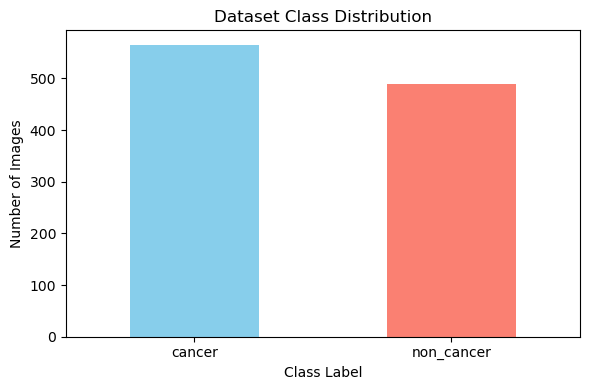

In [58]:
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Dataset Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png')
print("Saved class distribution plot to 'class_distribution.png'")

DATA CLEANING

In [59]:
print("Checking for corrupted images...")
valid_images = []
for idx, row in df.iterrows():
    try:
        with Image.open(row['path']) as img:
            img.verify()
        valid_images.append(idx)
    except Exception as e:
        print(f"Skipping corrupted file: {row['path']}")

df_clean = df.iloc[valid_images].reset_index(drop=True)
print(f"Dataset size after cleaning: {len(df_clean)}")

Checking for corrupted images...
Skipping corrupted file: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\200.jpeg
Skipping corrupted file: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\101.jpeg
Skipping corrupted file: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\450.jpeg
Skipping corrupted file: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\328.jpeg
Skipping corrupted file: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\317.jpeg
Skipping corrupted file: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\273.jpeg
Skipping corrupted file: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new\CANCER\481.jpeg
Skipping corrupted file: C:\Users\venun\OneDrive\Desktop\PAD\Oral cancer Dataset 2.0\OC Dataset kaggle new

DATA AUGMENTATION

In [60]:
# We use data augmentation (rotation, zoom, flips) to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=(0.8, 1.2),
    rotation_range=20,        
    width_shift_range=0.1,    
    height_shift_range=0.1,   
    horizontal_flip=True,     
    vertical_flip=True,
    fill_mode='nearest',
    shear_range=0.15,       
    zoom_range=0.15,          
    validation_split=0.2, 
)

# Validation set should only be rescaled, not augmented
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Size for MobileNet

train_gen = train_datagen.flow_from_dataframe(
    dataframe=df_clean,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=df_clean,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 836 validated image filenames belonging to 2 classes.


Found 209 validated image filenames belonging to 2 classes.


VISUALIZATION OF DATA AUGMENTATION

Saved augmented sample plot to 'augmented_samples.png'


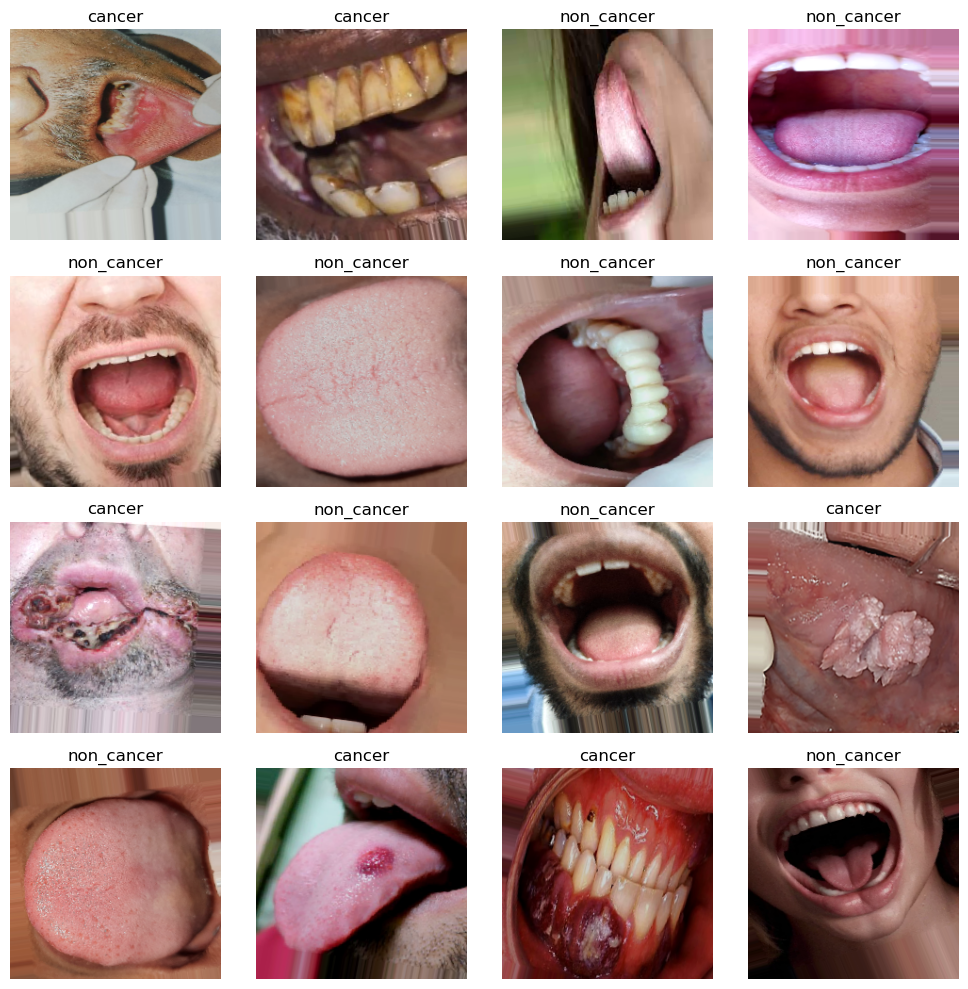

In [61]:
# Fetch one batch from the generator to visualize what the augmented data looks like
x_batch, y_batch = next(train_gen)

plt.figure(figsize=(10, 10))

for i in range(16): # Show first 16 images in the batch
    plt.subplot(4, 4, i+1)
    plt.imshow(x_batch[i])
    label_name = list(train_gen.class_indices.keys())[list(train_gen.class_indices.values()).index(int(y_batch[i]))]
    plt.title(label_name)
    plt.axis('off')
plt.tight_layout()
plt.savefig('augmented_samples.png')
print("Saved augmented sample plot to 'augmented_samples.png'")

CLASS WEIGHTING

In [62]:
# This mathematically forces the model to pay equal attention to CANCER 
# even if there are more NON-CANCER images in the dataset.
labels = train_gen.classes
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(weights))
print(f"Applying class weights to handle imbalance: {class_weights}")

Applying class weights to handle imbalance: {0: 0.954337899543379, 1: 1.050251256281407}


MODEL CREATION

In [63]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False, 
    weights='imagenet'
)

# Freeze base model layers initially
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.3)(x) 
output_layer = Dense(1, activation='sigmoid')(x) 

model = Model(inputs=base_model.input, outputs=output_layer)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

CALL BACKS

In [64]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('improved_oral_cancer_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

TRAINING (TRAIN THE TOP LAYERS)

In [66]:
print("\nStarting Phase 1 Training (Training custom top layers)...")
history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weights, 
    callbacks=callbacks
)


Starting Phase 1 Training (Training custom top layers)...
Epoch 1/10
11/27 ━━━━━━━━━━━━━━━━━━━━ 12s 806ms/step - accuracy: 0.7724 - loss: 2.7569

c:\Users\venun\anaconda3\New folder\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7885 - loss: 2.7247
Epoch 1: val_accuracy improved from None to 0.88038, saving model to improved_oral_cancer_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.8110 - loss: 2.6424 - val_accuracy: 0.8804 - val_loss: 2.2893 - learning_rate: 0.0010
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8567 - loss: 2.2939
Epoch 2: val_accuracy did not improve from 0.88038
27/27 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.8636 - loss: 2.1996 - val_accuracy: 0.8756 - val_loss: 2.0243 - learning_rate: 0.0010
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8592 - loss: 2.0042
Epoch 3: val_accuracy improved from 0.88038 to 0.88517, saving model to improved_oral_cancer_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.8553 - loss: 1.9647 - val_accuracy: 0.8852 - val_loss: 1.7836 - learning_rate: 0.0010
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8792 - loss: 1.7557
Epoc

FINE TUNING

In [67]:
print("\nStarting Phase 2 Training (Fine-tuning the base model)...")
base_model.trainable = True

# Freeze the first half of the layers to only fine-tune the deeper layers
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with a very low learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    epochs=10, 
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks
)


Starting Phase 2 Training (Fine-tuning the base model)...
Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8184 - loss: 1.2043
Epoch 1: val_accuracy did not improve from 0.91388
27/27 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.8206 - loss: 1.1723 - val_accuracy: 0.8947 - val_loss: 1.0254 - learning_rate: 1.0000e-05
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8362 - loss: 1.1255
Epoch 2: val_accuracy did not improve from 0.91388
27/27 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.8289 - loss: 1.1554 - val_accuracy: 0.8900 - val_loss: 1.0165 - learning_rate: 1.0000e-05
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8412 - loss: 1.1099
Epoch 3: val_accuracy did not improve from 0.91388
27/27 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.8409 - loss: 1.1404 - val_accuracy: 0.8852 - val_loss: 1.0127 - learning_rate: 1.0000e-05
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8493 - loss: 1.1046
Epoch 4: val_accuracy did 

MEITRICS

In [70]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
print(acc)
print(val_acc)
print(loss)
print(val_loss) 

[0.8110047578811646, 0.8636363744735718, 0.8552631735801697, 0.8684210777282715, 0.8839712738990784, 0.8468899726867676, 0.8672248721122742, 0.8839712738990784, 0.8911483287811279, 0.8791866302490234, 0.820574164390564, 0.8289473652839661, 0.8409090638160706, 0.8468899726867676, 0.8732057213783264, 0.8612440228462219, 0.8433014154434204, 0.8732057213783264]
[0.880382776260376, 0.8755980730056763, 0.8851674795150757, 0.9138755798339844, 0.8899521827697754, 0.8947368264198303, 0.89952152967453, 0.9138755798339844, 0.8851674795150757, 0.8947368264198303, 0.8947368264198303, 0.8899521827697754, 0.8851674795150757, 0.8851674795150757, 0.8947368264198303, 0.89952152967453, 0.89952152967453, 0.89952152967453]
[2.642421007156372, 2.199632167816162, 1.9646711349487305, 1.769361972808838, 1.57695734500885, 1.50479257106781, 1.3848726749420166, 1.243360161781311, 1.143273949623108, 1.0762245655059814, 1.172292947769165, 1.1553525924682617, 1.1404350996017456, 1.1297187805175781, 1.102738261222839

In [71]:
# Print the best validation accuracy achieved during training
best_val_acc = max(val_acc)
print(f"The highest validation accuracy achieved is: {best_val_acc * 100:.2f}%")

The highest validation accuracy achieved is: 91.39%


DATA VISUALIZATION

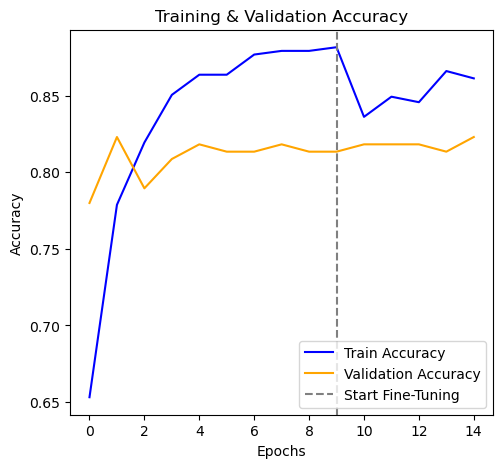

In [14]:
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
# Adding a vertical line where fine-tuning starts
plt.axvline(x=len(history1.epoch)-1, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

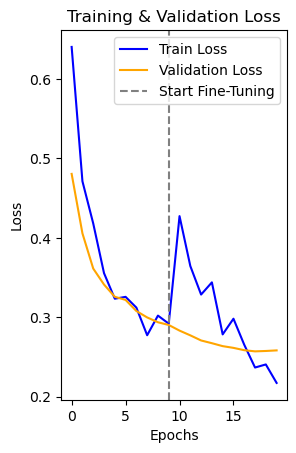

In [43]:
# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.axvline(x=len(history_phase1.epoch)-1, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()